29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - kl_loss: 2.0826 - loss: 37.1643 - recon_loss: 35.0817
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - kl_loss: 2.1141 - loss: 34.1295 - recon_loss: 32.0154
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - kl_loss: 2.1455 - loss: 33.6975 - recon_loss: 31.5520
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 2.2070 - loss: 34.7197 - recon_loss: 32.5127
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - kl_loss: 2.2369 - loss: 35.8183 - recon_loss: 33.5814
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - kl_loss: 2.3048 - loss: 35.1519 - recon_loss: 32.8471
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - kl_loss: 2.2598 - loss: 33.8059 - recon_loss: 31.5462
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/

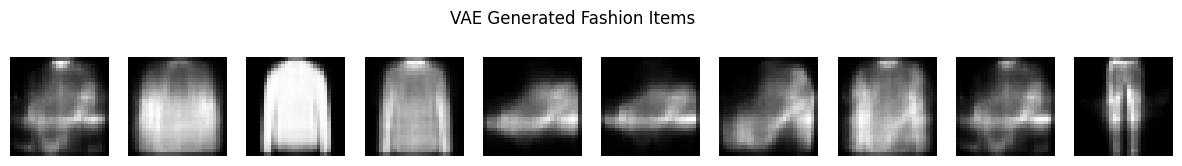

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

# ── 1. Load & Normalize Data ──────────────────────────────────────────────────
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1] and flatten 28x28 → 784
# VAE works on probabilities, so [0,1] range is essential
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

# ── 2. Sampling Layer (The "V" in VAE) ───────────────────────────────────────
# Instead of encoding to a fixed point, VAE encodes to (mean, log_variance)
# We then SAMPLE from that distribution → adds randomness → enables generation
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        # Reparameterization trick: z = mean + std * epsilon
        # This keeps gradients flowing through the random operation
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# ── 3. Encoder ────────────────────────────────────────────────────────────────
latent_dim = 2  # 2D so we can visualize the latent space easily

inputs   = tf.keras.Input(shape=(784,))
x        = layers.Dense(256, activation="relu")(inputs)  # Compress
z_mean   = layers.Dense(latent_dim)(x)                   # Mean vector
z_log_var= layers.Dense(latent_dim)(x)                   # Log variance vector
z        = Sampling()([z_mean, z_log_var])               # Sample from distribution

encoder  = Model(inputs, [z_mean, z_log_var, z], name="encoder")

# ── 4. Decoder ────────────────────────────────────────────────────────────────
# Takes a point in latent space → reconstructs 784-dim image
latent_inputs = tf.keras.Input(shape=(latent_dim,))
x    = layers.Dense(256, activation="relu")(latent_inputs)
outputs = layers.Dense(784, activation="sigmoid")(x)  # sigmoid keeps output in [0,1]

decoder = Model(latent_inputs, outputs, name="decoder")

# ── 5. VAE Model with Custom Loss ─────────────────────────────────────────────
# VAE loss = Reconstruction loss + KL Divergence
# KL loss forces the latent distribution to stay close to N(0,1)
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            # Reconstruction: how well did we rebuild the image?
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction)
                )
            )

            # KL Divergence: how close is latent space to N(0,1)?
            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = recon_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

# ── 6. Train ──────────────────────────────────────────────────────────────────
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.fit(x_train, epochs=10, batch_size=128)

# ── 7. Generate New Images ────────────────────────────────────────────────────
# Sample random points from N(0,1) → decode them → new fashion items!
random_latent = np.random.normal(size=(10, latent_dim))
generated = decoder.predict(random_latent)

plt.figure(figsize=(15, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(generated[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.suptitle("VAE Generated Fashion Items")
plt.show()